# The HD shoulder: why the SNR curve saturates twice

**Question.** The full-covariance HD SNR curve rises linearly, flattens near $\rho\approx0.5$ around $r\sim10^{-5}$ to $10^{-4}$, then rises again. The feature appears at every $N$ tried. What causes it, and is it physical?

**Approach.** Each claim below is tested with a controlled numerical experiment:

1. Baseline curve at fine $r$ sampling, with the local log-log slope.
2. Numerical trust: the result is checked with two independent linear solves and the residual, and compared to the pipeline's eigenvalue-cutoff path.
3. **Control experiment:** replace $\Gamma_{ab}$ by its field mean, then restore its variation in steps.
4. CP mechanism from the eigenmodes of $G=\Gamma\circ\Gamma$, with predicted onset of each mode.
5. HD mechanism: the part of $\rho^2$ that comes from $\Gamma$ variation.
6. Dependence on $N$.
7. Dependence on field of view.

The conclusions are collected at the end.

**Conventions.** Everything uses `main.py` and `hd_full_matrix_snr.py` from the same folder, so `POL_FACTOR` (the factor on $P_{ab}$) and `NORMALIZED_GAMMA` come from `main.py`. $r=P_{gw}(f_l)/P_n$. HD is computed with a direct dense solve of $M(r)\,y=\mathbf{1}$, $\rho^2=2\,\mathbf{1}^T y$, which limits HD to $N\lesssim60$ here.

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.getcwd())
import main as M
import hd_full_matrix_snr as H

# main.py selects the Agg backend for Slurm; switch back to inline plots here.
%matplotlib inline

c  = M.POL_FACTOR
F  = M.gamma_scale_factor()
print(f"POL_FACTOR = {c},  F = {F:.1f},  NORMALIZED_GAMMA = {M.NORMALIZED_GAMMA}")

# Plot style. Categorical colors in fixed order; line styles give a second
# encoding so series are distinguishable without color.
COL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]
LS  = ["-", "--", "-.", ":", (0, (5, 1, 1, 1)), (0, (1, 1))]
CP_COL, HD_COL = COL[0], COL[1]
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2,
    "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 9, "legend.frameon": False,
})

POL_FACTOR = 2.0,  F = 5953.2,  NORMALIZED_GAMMA = True


In [2]:
def make_field(N, fov_deg, seed=M.RANDOM_SEED, ell_max=None):
    # Star field -> (Gamma matrix with NaN diagonal, gamma0, ell_min, ell_max).
    stars = M.build_star_positions(None, N, fov_deg, seed)
    theta = M.pairwise_theta(stars)
    ell_min, lmax = M.compute_ell_limits(theta, fov_deg)
    if ell_max is not None:
        lmax = ell_max
    gam = M.gamma_parallel_matrix(theta, ell_min, lmax, batch_size=20000)
    g0 = M.cp_single_star_gamma(ell_min, lmax)
    return gam, g0, ell_min, lmax


def hd_rho(gam, g0, r_arr, want_cond=False):
    # Full-covariance HD SNR by direct solve.
    # Returns rho, a trust flag per r, and optionally cond(M(r)).
    # Trust flag: the plain solve and a Jacobi-equilibrated solve agree to 1e-6.
    _, A, B, D = H.build_HD_matrices(gam, g0)
    one = np.ones(A.shape[0])
    rho, ok, cond = [], [], []
    for r in np.atleast_1d(r_arr):
        Mr = A + B / r + D / r**2
        x1 = np.linalg.solve(Mr, one)
        s = 1.0 / np.sqrt(np.diag(Mr))
        x2 = s * np.linalg.solve(Mr * np.outer(s, s), s)
        r1, r2 = np.sqrt(2 * x1.sum()), np.sqrt(2 * x2.sum())
        rho.append(r1); ok.append(abs(r1 / r2 - 1) < 1e-6)
        if want_cond:
            cond.append(np.linalg.cond(Mr))
    out = (np.array(rho), np.array(ok))
    return out + (np.array(cond),) if want_cond else out


def cp_rho(gam, g0, ell_min, ell_max, r_arr):
    return M.rho_cp_full(r_arr, gam, ell_min, ell_max, verbose=False)


def log_slope(r, rho):
    return np.gradient(np.log10(rho), np.log10(r))


def first_plateau(r, rho):
    # First saturation: the first local minimum of the log-log slope after the
    # slope has dropped below 0.5. Returns (r, rho, slope) at that point.
    s = log_slope(r, rho)
    i = np.argmax(s < 0.5)
    while i + 1 < len(s) and s[i + 1] <= s[i]:
        i += 1
    return r[i], rho[i], s[i]


def with_uniform_mix(gam, alpha):
    # Gamma_ab -> mean + alpha * (Gamma_ab - mean). alpha=0 is uniform, 1 is real.
    iu = np.triu_indices_from(gam, 1)
    m = gam[iu].mean()
    out = m + alpha * (gam - m)
    np.fill_diagonal(out, np.nan)
    return out

## 1. Baseline: two saturation stages

$N=30$ stars in a $10^\circ$ field, 10 points per decade (far finer than the pipeline's `n_r=30`). The lower panel shows the local slope $d\log\rho/d\log r$: 1 means linear growth, 0 means a plateau. A second rise after a near-zero minimum is what makes the curve look like it has a dip.

N=30, FoV=10 deg, ell_max=7327, gamma0=1.0000
off-diagonal Gamma: min 0.9539, mean 0.9866, max 1.0000


computed in 3.9s; all HD points pass the solver check: True
HD first plateau: slope 0.071 at r = 6.3e-05, rho = 0.486;  rho(10) = 1.401  (2.88x the first plateau)
CP first plateau: slope 0.008 at r = 7.9e-04, rho = 0.507;  rho(10) = 0.672  (1.33x the first plateau)


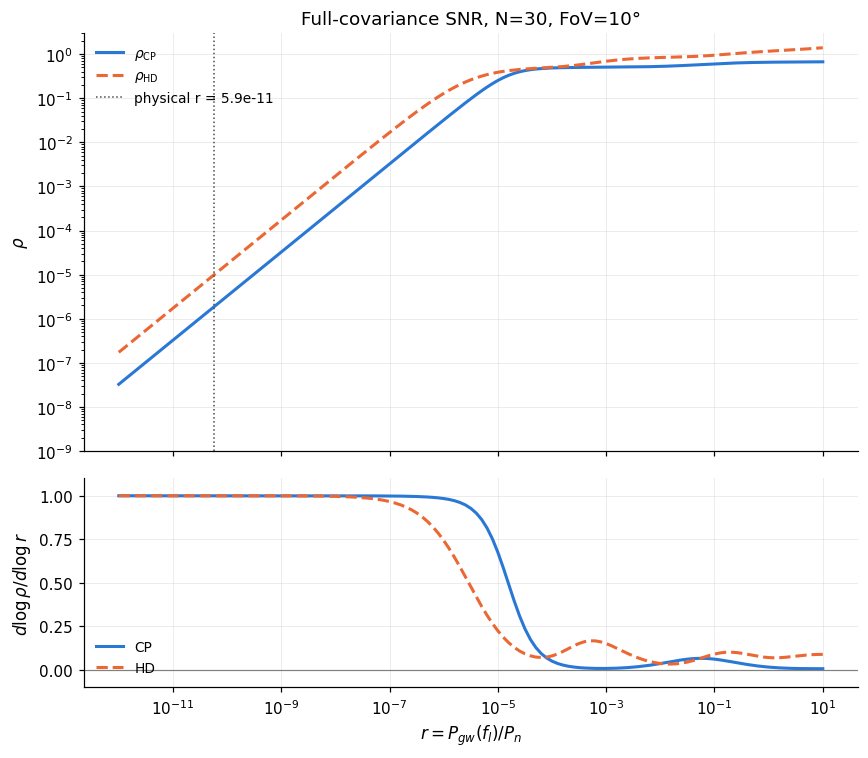

In [3]:
N0, FOV0 = 30, 10
gam0, g00, lmin0, lmax0 = make_field(N0, FOV0)
iu = np.triu_indices(N0, 1)
print(f"N={N0}, FoV={FOV0} deg, ell_max={lmax0}, gamma0={g00:.4f}")
print(f"off-diagonal Gamma: min {gam0[iu].min():.4f}, mean {gam0[iu].mean():.4f}, max {gam0[iu].max():.4f}")

r = np.logspace(-12, 1, 131)
t = time.time()
hd0, ok0, cond0 = hd_rho(gam0, g00, r, want_cond=True)
cp0 = cp_rho(gam0, g00, lmin0, lmax0, r)
print(f"computed in {time.time()-t:.1f}s; all HD points pass the solver check: {ok0.all()}")

s_hd, s_cp = log_slope(r, hd0), log_slope(r, cp0)
for name, y in [("HD", hd0), ("CP", cp0)]:
    rp, yp, sp = first_plateau(r, y)
    print(f"{name} first plateau: slope {sp:.3f} at r = {rp:.1e}, rho = {yp:.3f};  rho(10) = {y[-1]:.3f}  ({y[-1]/yp:.2f}x the first plateau)")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax1.loglog(r, cp0, color=CP_COL, ls=LS[0], label=r"$\rho_{\rm CP}$")
ax1.loglog(r, hd0, color=HD_COL, ls=LS[1], label=r"$\rho_{\rm HD}$")
ax1.axvline(M.PHYSICAL_RATIO, color="0.3", lw=1, ls=":", label=f"physical r = {M.PHYSICAL_RATIO:.1e}")
ax1.set_ylabel(r"$\rho$"); ax1.set_ylim(1e-9, 3); ax1.legend(loc="upper left")
ax1.set_title(f"Full-covariance SNR, N={N0}, FoV={FOV0}°")
ax2.semilogx(r, s_cp, color=CP_COL, ls=LS[0], label="CP")
ax2.semilogx(r, s_hd, color=HD_COL, ls=LS[1], label="HD")
ax2.axhline(0, color="0.5", lw=0.8)
ax2.set_ylabel(r"$d\log\rho / d\log r$"); ax2.set_xlabel(r"$r = P_{gw}(f_l)/P_n$")
ax2.set_ylim(-0.1, 1.1); ax2.legend(loc="lower left")
plt.tight_layout(); plt.show()

## 2. Is the second rise numerical?

Above $r\sim10^{-2}$ the pair covariance $M(r)$ becomes ill-conditioned, so the second rise needs a numerical check before it is reported. Three checks are applied:

- **Condition number** of $M(r)$. Double precision loses roughly $\log_{10}\kappa$ of its 16 digits.
- **Two independent solves**, the plain solve and a Jacobi-equilibrated solve, compared to $10^{-6}$.
- **Relative residual** $\|M y - \mathbf 1\|/\|\mathbf 1\|$.

The table also shows the pipeline's dense path (`rho_hd_full_matrix_dense`, which drops eigenvalues below $10^{-10}\,\lambda_{\max}$) to show how much that cutoff removes.

       r    cond(M)      solve  equilibrated   residual  pipeline eig-cut
   1e-06    1.9e+00    0.12908       0.12908    4.7e-16           0.12908
   1e-04    1.3e+03    0.50321       0.50321    3.5e-16           0.50321
   1e-02    1.2e+07    0.84213       0.84213    1.6e-14           0.84213
   1e-01    1.2e+09    0.94868       0.94868    4.1e-13           0.94868
   1e+00    1.2e+11    1.16828       1.16828    3.7e-12           1.14864
   1e+01    1.2e+13    1.40081       1.40081    6.9e-11           1.20615


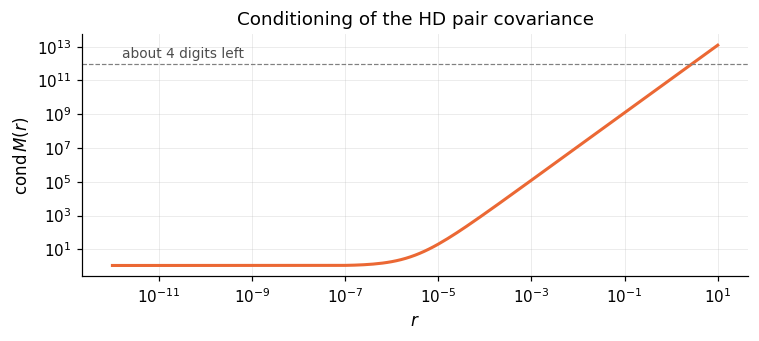

In [4]:
r_chk = np.array([1e-6, 1e-4, 1e-2, 1e-1, 1.0, 10.0])
_, A0, B0, D0 = H.build_HD_matrices(gam0, g00)
pipe = H.rho_hd_full_matrix_dense(r_chk, gam0, g00, verbose=False)
one = np.ones(A0.shape[0])
print(f"{'r':>8} {'cond(M)':>10} {'solve':>10} {'equilibrated':>13} {'residual':>10} {'pipeline eig-cut':>17}")
for rv, pv in zip(r_chk, pipe):
    Mr = A0 + B0 / rv + D0 / rv**2
    x1 = np.linalg.solve(Mr, one)
    s = 1 / np.sqrt(np.diag(Mr)); x2 = s * np.linalg.solve(Mr * np.outer(s, s), s)
    res = np.linalg.norm(Mr @ x1 - one) / np.linalg.norm(one)
    print(f"{rv:8.0e} {np.linalg.cond(Mr):10.1e} {np.sqrt(2*x1.sum()):10.5f} {np.sqrt(2*x2.sum()):13.5f} {res:10.1e} {pv:17.5f}")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.loglog(r, cond0, color=HD_COL)
ax.axhline(1e12, color="0.5", lw=0.8, ls="--")
ax.text(r[2], 2e12, "about 4 digits left", fontsize=9, color="0.3")
ax.set_xlabel(r"$r$"); ax.set_ylabel(r"cond$\,M(r)$"); ax.set_title("Conditioning of the HD pair covariance")
plt.tight_layout(); plt.show()

**Reading.** Up to $r=10$ the two solves agree and the residuals stay far below the precision of the result, so the second rise is a converged property of the covariance and not round-off. The pipeline's eigenvalue cutoff is what goes wrong at large $r$: it discards the small eigenvalues of $M$, which are exactly the modes that carry the second rise, so it underestimates $\rho_{\rm HD}$ there. For numbers above $r\sim10^{-2}$, use a direct solve (dense) or tighter iterative tolerances.

## 3. Control experiment: uniform $\Gamma$

**Hypothesis.** The first plateau comes from the common part of $\Gamma_{ab}$ (all pairs nearly equal), and the second rise comes from how $\Gamma_{ab}$ varies with separation.

**Test.** Replace $\Gamma_{ab}\to\bar\Gamma+\alpha(\Gamma_{ab}-\bar\Gamma)$ with $\Gamma(0)$ unchanged:
- $\alpha=0$: every pair has the same $\Gamma$ (no variation).
- $\alpha=1$: the real field.

If the hypothesis holds, $\alpha=0$ should saturate once with no second rise, and the second rise should grow with $\alpha$. Values of $\alpha$ that make $G=\Gamma\circ\Gamma$ lose positive semidefiniteness are skipped, since they do not describe a valid covariance.

alpha= 0.0: min eig(G)= 2.66e-02  rho_HD(1e-4)=0.486  rho_HD(10)=0.500  rho_CP(1e-4)=0.487  rho_CP(10)=0.507  solver ok: True


alpha= 0.1: min eig(G)= 2.40e-02  rho_HD(1e-4)=0.486  rho_HD(10)=0.655  rho_CP(1e-4)=0.487  rho_CP(10)=0.507  solver ok: True


alpha= 0.3: min eig(G)= 1.87e-02  rho_HD(1e-4)=0.488  rho_HD(10)=0.781  rho_CP(1e-4)=0.487  rho_CP(10)=0.509  solver ok: True


alpha= 1.0: min eig(G)= 2.77e-10  rho_HD(1e-4)=0.503  rho_HD(10)=1.401  rho_CP(1e-4)=0.487  rho_CP(10)=0.672  solver ok: True


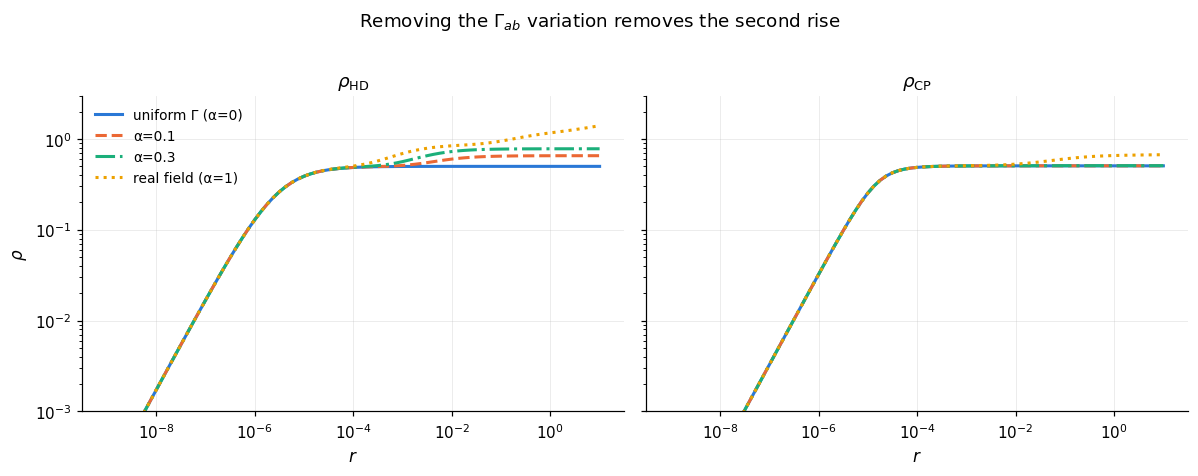

In [5]:
alphas = [0.0, 0.1, 0.3, 1.0]
r3 = np.logspace(-9, 1, 81)
res3 = {}
for a in alphas:
    ga = with_uniform_mix(gam0, a)
    ev_min = np.linalg.eigvalsh(M.cp_gamma_matrix(ga, g00) ** 2).min()
    h, ok = hd_rho(ga, g00, r3)
    cpa = cp_rho(ga, g00, lmin0, lmax0, r3)
    res3[a] = (h, cpa, ok)
    print(f"alpha={a:4.1f}: min eig(G)={ev_min:9.2e}  rho_HD(1e-4)={np.interp(-4, np.log10(r3), h):.3f}  "
          f"rho_HD(10)={h[-1]:.3f}  rho_CP(1e-4)={np.interp(-4, np.log10(r3), cpa):.3f}  rho_CP(10)={cpa[-1]:.3f}  solver ok: {ok.all()}")

fig, axs = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for i, a in enumerate(alphas):
    h, cpa, _ = res3[a]
    lab = "uniform Γ (α=0)" if a == 0 else ("real field (α=1)" if a == 1 else f"α={a}")
    axs[0].loglog(r3, h, color=COL[i], ls=LS[i], label=lab)
    axs[1].loglog(r3, cpa, color=COL[i], ls=LS[i], label=lab)
axs[0].set_title(r"$\rho_{\rm HD}$"); axs[1].set_title(r"$\rho_{\rm CP}$")
for ax in axs:
    ax.set_xlabel(r"$r$"); ax.set_ylim(1e-3, 3)
axs[0].set_ylabel(r"$\rho$"); axs[0].legend(loc="upper left")
fig.suptitle(r"Removing the $\Gamma_{ab}$ variation removes the second rise", y=1.02)
plt.tight_layout(); plt.show()

**Reading.** With uniform $\Gamma$ both curves saturate once and stay flat. The first plateau is the same for every $\alpha$, and the height of the second rise scales with the size of the $\Gamma_{ab}$ variation. This isolates the cause: **the first plateau comes from the common mode of $\Gamma$, and the second rise comes from the variation of $\Gamma_{ab}$ across the field.**

## 4. CP mechanism: eigenmodes of $G=\Gamma\circ\Gamma$

For CP the inverse is exact in the eigenbasis $G=V\,{\rm diag}(g)\,V^T$:

$$\rho_{\rm CP}^2=\frac{1}{c^2}\sum_k\frac{s_k^2}{g_k+\lambda(r)},\qquad s_k=\mathbf 1^Tv_k,\qquad \lambda(r)=\frac{2\gamma_0}{p}+\frac{1}{p^2},\quad p=cFr.$$

Mode $k$ contributes only once the noise term $\lambda(r)$ falls below its eigenvalue $g_k$. Setting $\lambda(r_k)=g_k$ gives a predicted onset

$$r_k=\frac{\gamma_0+\sqrt{\gamma_0^2+g_k}}{cF\,g_k}.$$

Near-uniform $\Gamma$ gives one large eigenvalue $g_1\approx N\gamma_0^2$ with almost all of the weight $s_1^2\approx N$. It saturates first at $\rho\approx1/(c\gamma_0)$. All other modes have eigenvalues that are orders of magnitude smaller, so they turn on at much larger $r$.

top mode: g1 = 29.234 (N*gamma0^2 = 30.000), s1^2 = 29.99816 of N = 30
next five eigenvalues: [0.502 0.255 0.005 0.002 0.002]
top-mode plateau 1/(c*sqrt(g1/s1^2)) = 0.5065;  1/(c*gamma0) = 0.5000
predicted onsets r_k for modes 1-6: 1.9e-05, 3.7e-04, 7.0e-04, 3.7e-02, 7.2e-02, 1.1e-01
dotted lines: onset of the top mode and of modes [5 6 4] (largest s_k^2/g_k)


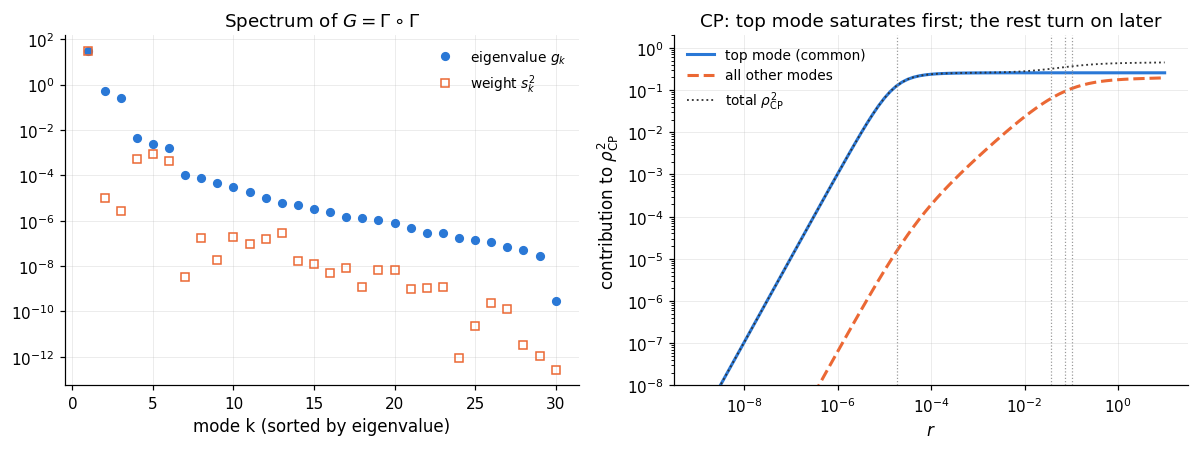

In [6]:
g, s2 = M.cp_covariance_eigensystem(gam0, g00, verbose=False)
o = np.argsort(g)[::-1]; g, s2 = g[o], s2[o]
print(f"top mode: g1 = {g[0]:.3f} (N*gamma0^2 = {N0*g00**2:.3f}), s1^2 = {s2[0]:.5f} of N = {N0}")
print(f"next five eigenvalues: {np.array2string(g[1:6], precision=3)}")
print(f"top-mode plateau 1/(c*sqrt(g1/s1^2)) = {np.sqrt(s2[0]/g[0])/c:.4f};  1/(c*gamma0) = {1/(c*g00):.4f}")

p = c * F * r3
lam = 2 * g00 / p + 1 / p**2
contrib = s2[None, :] / (g[None, :] + lam[:, None]) / c**2
top, rest = contrib[:, 0], contrib[:, 1:].sum(1)
r_on = (g00 + np.sqrt(g00**2 + g)) / (c * F * g)
print("predicted onsets r_k for modes 1-6:", ", ".join(f"{x:.1e}" for x in r_on[:6]))

fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))
axs[0].semilogy(np.arange(1, len(g) + 1), np.clip(g, 1e-16, None), "o", color=CP_COL, ms=5, label=r"eigenvalue $g_k$")
axs[0].semilogy(np.arange(1, len(g) + 1), np.clip(s2, 1e-16, None), "s", color=HD_COL, ms=5, mfc="none", label=r"weight $s_k^2$")
axs[0].set_xlabel("mode k (sorted by eigenvalue)"); axs[0].set_title(r"Spectrum of $G=\Gamma\circ\Gamma$"); axs[0].legend()
axs[1].loglog(r3, top, color=COL[0], ls=LS[0], label="top mode (common)")
axs[1].loglog(r3, rest, color=COL[1], ls=LS[1], label="all other modes")
axs[1].loglog(r3, top + rest, color="0.2", lw=1.2, ls=":", label=r"total $\rho_{\rm CP}^2$")
# mark predicted onsets of the top mode and of the three modes that carry the most weight at large r
big = 1 + np.argsort(s2[1:] / g[1:])[::-1][:3]
for rk in np.r_[r_on[0], r_on[big]]:
    axs[1].axvline(rk, color="0.6", lw=0.8, ls=":")
print("dotted lines: onset of the top mode and of modes", big + 1, "(largest s_k^2/g_k)")
axs[1].set_ylim(1e-8, 2); axs[1].set_xlabel(r"$r$"); axs[1].set_ylabel(r"contribution to $\rho_{\rm CP}^2$")
axs[1].set_title("CP: top mode saturates first; the rest turn on later"); axs[1].legend(loc="upper left")
plt.tight_layout(); plt.show()

**Reading.** The common mode alone produces the first CP plateau at $1/(c\gamma_0)$. The remaining modes contribute nothing until $r$ passes their predicted onsets (dotted lines), which are orders of magnitude later, and then they supply the second rise. The gap between the two stages is set by the ratio of the top eigenvalue to the subleading ones, which is set by how uniform $\Gamma_{ab}$ is across the field.

## 5. HD mechanism: the contribution of $\Gamma$ variation

HD has no single eigenbasis for all $r$, since $M(r)=A+B/r+D/r^2$ and the three terms do not commute. The uniform-$\Gamma$ control from Section 3 gives a direct decomposition instead:

$$\rho^2_{\rm HD}(r)=\underbrace{\rho^2_{\rm HD,\ uniform}(r)}_{\text{common mode}}+\underbrace{\Delta\rho^2(r)}_{\text{from }\Gamma\text{ variation}}.$$

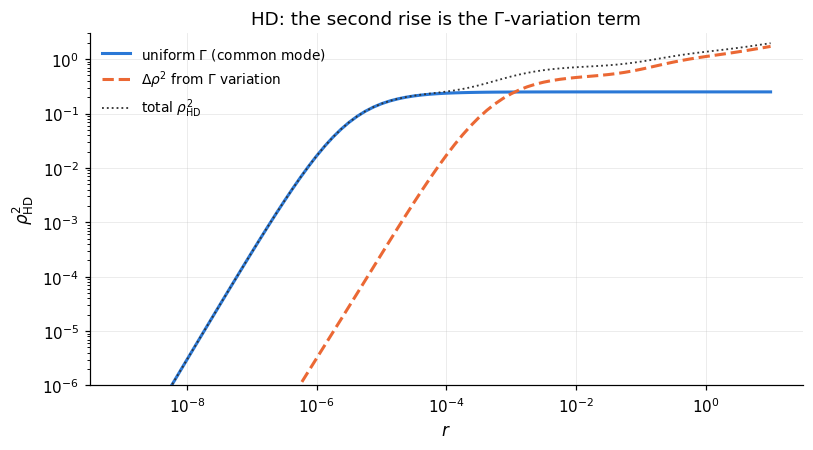

at r=1e-4: common mode 0.236, variation term 0.017
at r=10  : common mode 0.250, variation term 1.712


In [7]:
h_real, h_unif = res3[1.0][0], res3[0.0][0]
dr2 = h_real**2 - h_unif**2
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.loglog(r3, h_unif**2, color=COL[0], ls=LS[0], label=r"uniform $\Gamma$ (common mode)")
ax.loglog(r3, np.clip(dr2, 1e-12, None), color=COL[1], ls=LS[1], label=r"$\Delta\rho^2$ from $\Gamma$ variation")
ax.loglog(r3, h_real**2, color="0.2", lw=1.2, ls=":", label=r"total $\rho^2_{\rm HD}$")
ax.set_ylim(1e-6, 3); ax.set_xlabel(r"$r$"); ax.set_ylabel(r"$\rho^2_{\rm HD}$")
ax.set_title("HD: the second rise is the Γ-variation term"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()
k = np.argmin(abs(r3 - 1e-4))
print(f"at r=1e-4: common mode {h_unif[k]**2:.3f}, variation term {dr2[k]:.3f}")
print(f"at r=10  : common mode {h_unif[-1]**2:.3f}, variation term {dr2[-1]:.3f}")

## 6. Dependence on $N$

`ell_max` is held fixed across $N$ here. Otherwise it changes with the closest star pair in each random draw, and $\Gamma$ changes with it. HD is dense, so $N\le60$. CP uses the exact eigen-solution and extends to larger $N$.

   N  HD 1st plateau r  rho there  slope  HD rho(10)


  20           1.0e-04      0.486  0.066       1.333   solver ok: True


  30           5.6e-05      0.483  0.072       1.401   solver ok: True


  40           4.2e-05      0.482  0.070       1.493   solver ok: True


  60           3.2e-05      0.485  0.068       1.611   solver ok: True

   N  CP onset 1/(sqrt(N)cF g0)  CP first plateau  CP rho(10)


  20                   1.88e-05             0.506       0.667


  40                   1.33e-05             0.506       0.676


  80                   9.39e-06             0.506       0.682


 160                   6.64e-06             0.507       0.688


 320                   4.70e-06             0.507       0.692


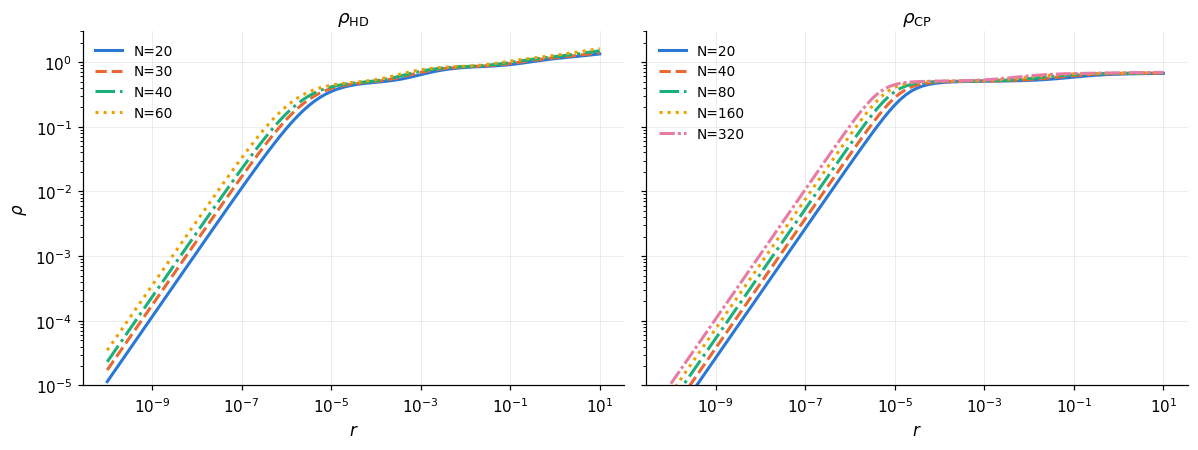

In [8]:
ELL_FIX = 4000
Ns_hd = [20, 30, 40, 60]
Ns_cp = [20, 40, 80, 160, 320]
r6 = np.logspace(-10, 1, 89)
fields = {}
fig, axs = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
print(f"{'N':>4} {'HD 1st plateau r':>17} {'rho there':>10} {'slope':>6} {'HD rho(10)':>11}")
for i, N in enumerate(Ns_hd):
    fields[N] = make_field(N, FOV0, ell_max=ELL_FIX)
    gN, g0N, _, _ = fields[N]
    h, ok = hd_rho(gN, g0N, r6)
    rp, yp, sp = first_plateau(r6, h)
    print(f"{N:4d} {rp:17.1e} {yp:10.3f} {sp:6.3f} {h[-1]:11.3f}   solver ok: {ok.all()}")
    axs[0].loglog(r6, h, color=COL[i], ls=LS[i], label=f"N={N}")
print(f"\n{'N':>4} {'CP onset 1/(sqrt(N)cF g0)':>26} {'CP first plateau':>17} {'CP rho(10)':>11}")
for i, N in enumerate(Ns_cp):
    gN, g0N, lmin, lmax = make_field(N, FOV0, ell_max=ELL_FIX)
    cpN = cp_rho(gN, g0N, lmin, lmax, r6)
    gg, ss = M.cp_covariance_eigensystem(gN, g0N, verbose=False)
    k = np.argmax(gg)
    print(f"{N:4d} {1/(np.sqrt(N)*c*F*g0N):26.2e} {np.sqrt(ss[k]/gg[k])/c:17.3f} {cpN[-1]:11.3f}")
    axs[1].loglog(r6, cpN, color=COL[i], ls=LS[i], label=f"N={N}")
axs[0].set_title(r"$\rho_{\rm HD}$"); axs[1].set_title(r"$\rho_{\rm CP}$")
for ax in axs:
    ax.set_xlabel(r"$r$"); ax.set_ylim(1e-5, 3); ax.legend(loc="upper left")
axs[0].set_ylabel(r"$\rho$")
plt.tight_layout(); plt.show()

**Reading.** $N$ shifts the linear part (more stars and pairs, higher $\rho$ at fixed $r$), and the first saturation moves to lower $r$ only slowly (as $1/\sqrt N$ for CP). The first plateau height is nearly unchanged, since it is set by $c$ and $\gamma_0$, not $N$. This is why the shoulder is present at every $N$.

## 7. Dependence on field of view

Wider fields give a larger spread of $\Gamma_{ab}$. From Sections 3 to 5 this should strengthen the variation term and push the second rise to lower $r$, eventually merging the two stages. $N=30$ throughout, with `ell_max` from the field as in the pipeline. Points that fail the solver check are dropped.

Flatness = minimum HD log-slope after the first saturation (0 = perfectly flat shoulder).
 FoV  ell_max  Gamma spread  HD 1st plateau  flatness  HD rho(10)  CP rho(10)


   2    36636        0.0019           0.497     0.010       0.883       0.531


   5    14654        0.0118           0.492     0.031       1.150       0.626


  10     7327        0.0461           0.483     0.072       1.401       0.672


  30     2442        0.3549           0.841     0.084       1.895       0.805


  60     1221        0.9895           1.202     0.105       2.044       0.940


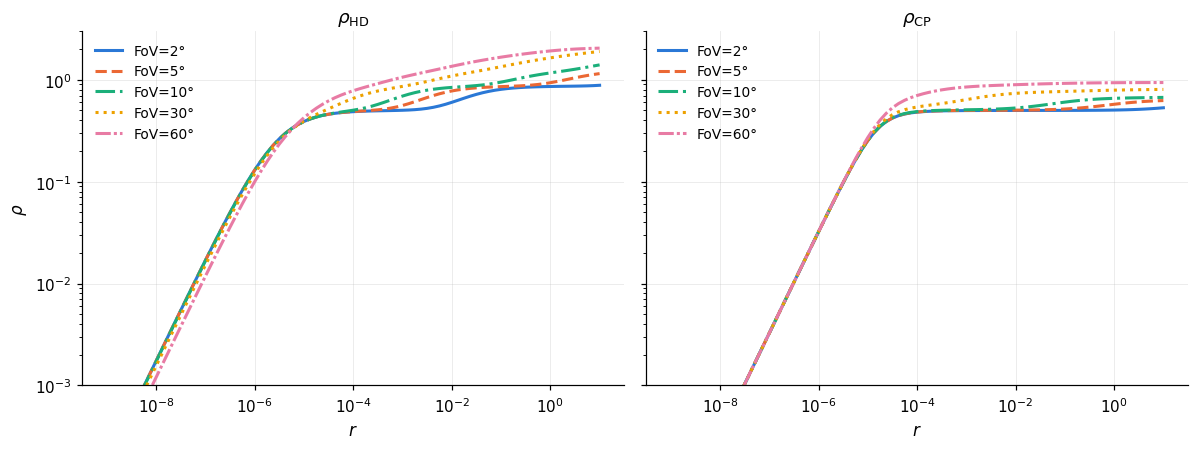

In [9]:
fovs = [2, 5, 10, 30, 60]
r7 = np.logspace(-9, 1, 81)
fig, axs = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
print("Flatness = minimum HD log-slope after the first saturation (0 = perfectly flat shoulder).")
print(f"{'FoV':>4} {'ell_max':>8} {'Gamma spread':>13} {'HD 1st plateau':>15} {'flatness':>9} {'HD rho(10)':>11} {'CP rho(10)':>11}")
for i, fov in enumerate(fovs):
    gF, g0F, lmin, lmax = make_field(N0, fov)
    spread = np.ptp(gF[np.triu_indices(N0, 1)])
    h, ok = hd_rho(gF, g0F, r7)
    cpF = cp_rho(gF, g0F, lmin, lmax, r7)
    h_plot = np.where(ok, h, np.nan)
    at = lambda y, x: np.interp(np.log10(x), np.log10(r7), y)
    rp, yp, sp = first_plateau(r7, h)
    print(f"{fov:4d} {lmax:8d} {spread:13.4f} {yp:15.3f} {sp:9.3f} {h_plot[-1]:11.3f} {cpF[-1]:11.3f}"
          + ("" if ok.all() else f"   ({(~ok).sum()} HD points failed the solver check)"))
    axs[0].loglog(r7, h_plot, color=COL[i], ls=LS[i], label=f"FoV={fov}°")
    axs[1].loglog(r7, cpF, color=COL[i], ls=LS[i], label=f"FoV={fov}°")
axs[0].set_title(r"$\rho_{\rm HD}$"); axs[1].set_title(r"$\rho_{\rm CP}$")
for ax in axs:
    ax.set_xlabel(r"$r$"); ax.set_ylim(1e-3, 3); ax.legend(loc="upper left")
axs[0].set_ylabel(r"$\rho$")
plt.tight_layout(); plt.show()

## Conclusions

Numbers are for $N=30$, FoV $=10^\circ$, `POL_FACTOR` $=2$, normalized $\Gamma$, unless stated.

1. **It is a staircase, not a dip.** $\rho_{\rm HD}$ rises linearly, flattens at a first plateau $\rho\approx0.49$ near $r\approx6\times10^{-5}$ (log-slope 0.07), then climbs again to 1.40 by $r=10$. $\rho_{\rm CP}$ does the same more weakly: first plateau 0.507 ($\approx1/(c\gamma_0)$), then 0.67 by $r=10$.
2. **It is not numerical.** Through $r=10$ (condition number $1.2\times10^{13}$) a plain and an equilibrated solve agree and the residual stays at or below $7\times10^{-11}$. The pipeline's eigenvalue cutoff is the part that fails there: it gives 1.149 instead of 1.168 at $r=1$, and 1.206 instead of 1.401 at $r=10$, because the discarded small eigenvalues carry the second rise.
3. **The cause is the variation of $\Gamma_{ab}$ across the field (control experiment).** With $\Gamma_{ab}$ set to its field mean, HD saturates once at 0.50 and CP at 0.51, with no second rise. Restoring the variation in steps ($\alpha=0,\,0.1,\,0.3,\,1$) gives $\rho_{\rm HD}(r=10)=0.50,\,0.66,\,0.78,\,1.40$, while the first plateau stays fixed.
4. **CP mechanism (exact).** The top eigenmode of $G=\Gamma\circ\Gamma$ has eigenvalue 29.2 ($\approx N\gamma_0^2=30$) and carries 29.998 of the total weight 30. It alone produces the first plateau at $1/(c\gamma_0)$, with predicted onset $1.9\times10^{-5}$. The next eigenvalues are 0.50 and 0.26, then $\lesssim5\times10^{-3}$, which puts their onsets between $4\times10^{-4}$ and $10^{-1}$. They produce the later steps.
5. **HD mechanism.** At $r=10^{-4}$ the $\Gamma$-variation term contributes 0.017 of $\rho^2_{\rm HD}=0.25$. At $r=10$ it contributes 1.71 against 0.25 from the common mode.
6. **Why it appears at every $N$.** The first-plateau height is set by $c$ and $\gamma_0$, not by $N$: HD 0.482 to 0.486 and CP 0.506 to 0.507 for $N$ from 20 to 320. $N$ only moves the onset, roughly as $1/N$ for HD ($1.0\times10^{-4}\to3.2\times10^{-5}$ for $N=20\to60$) and as $1/\sqrt N$ for CP.
7. **The field of view controls how pronounced it is.** As the $\Gamma_{ab}$ spread grows from 0.002 ($2^\circ$) to 0.99 ($60^\circ$), the minimum slope after the first saturation rises from 0.010 to 0.105, and the two stages merge. Narrow fields show the flattest shoulder.

**Interpretation.** The first plateau is the information available from the common part of the correlation, which is the same for all pairs in a narrow field and saturates at $\sim1/c$. The second rise is the extra information from how the correlation changes with separation, which is the angular signature itself. That information is weaker in narrow fields, so it needs a larger $r$ to show up.

**Practical notes.** The physical operating point at 1 mas ($r\approx6\times10^{-11}$) sits deep in the linear regime and is unaffected by any of this. For plots, use $\gtrsim7$ points per decade. For HD values above $r\sim10^{-1}$, use a direct solve rather than the eigenvalue cutoff.